In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="r3ErAguz5nLW7XElnGIW")
project = rf.workspace("mainel").project("mask-knkba")
version = project.version(1)
dataset = version.download("yolov11")
                

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 37.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 113.0 MB/s eta 0:00:0000:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.22.1 requires google-cloud-bigquery-s


Extracting Dataset Version Zip to mask-1 in yolov11:: 100%|██████████| 13744/13744 [00:01<00:00, 9788.88it/s] 


In [2]:
import os
os.listdir(dataset.location)

['train',
 'README.dataset.txt',
 'valid',
 'test',
 'data.yaml',
 'README.roboflow.txt']

In [3]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.6 MB/s eta 0:00:00a 0:00:01


In [4]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=25,
    imgsz=640,
    batch=16
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/mask-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79973a988a70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [7]:
data_set = "/kaggle/working/mask-1/data.yaml"
metrics = model.val(data=data_set)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 954.7±443.8 MB/s, size: 40.2 KB)
val: Scanning /kaggle/working/mask-1/valid/labels.cache... 582 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 582/582 244.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 37/37 6.0it/s 6.2s0.1s
                   all        582       1059      0.948      0.869      0.935      0.702
                     -        327        505      0.956      0.861      0.936      0.694
Mask Wearing - v6 roboflow train v3        292        554       0.94      0.877      0.934      0.709
Speed: 1.2ms preprocess, 3.8ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/val3


In [11]:
print("Precision:", metrics.box.p)  # precision for bounding boxes
print("Recall:", metrics.box.r)     # recall for bounding boxes
print("mAP50:", metrics.box.map50)  # mAP at IoU=0.5
print("mAP50-95:", metrics.box.map) # mAP averaged over IoU 0.5 to 0.95
print("F1 score:", metrics.box.f1)  # F1 score


Precision: [    0.95571     0.93963]
Recall: [    0.86139     0.87726]
mAP50: 0.934930911642031
mAP50-95: 0.7018104393646083
F1 score: [     0.9061     0.90737]


In [13]:
!ls "/kaggle/working/runs/detect/train/weights"

best.pt  last.pt


In [15]:
!ls "/kaggle/working/runs/detect/train"

args.yaml			 results.csv	      val_batch0_labels.jpg
BoxF1_curve.png			 results.png	      val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg     val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg     val_batch1_pred.jpg
BoxR_curve.png			 train_batch2.jpg     val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch5655.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch5656.jpg  weights
labels.jpg			 train_batch5657.jpg


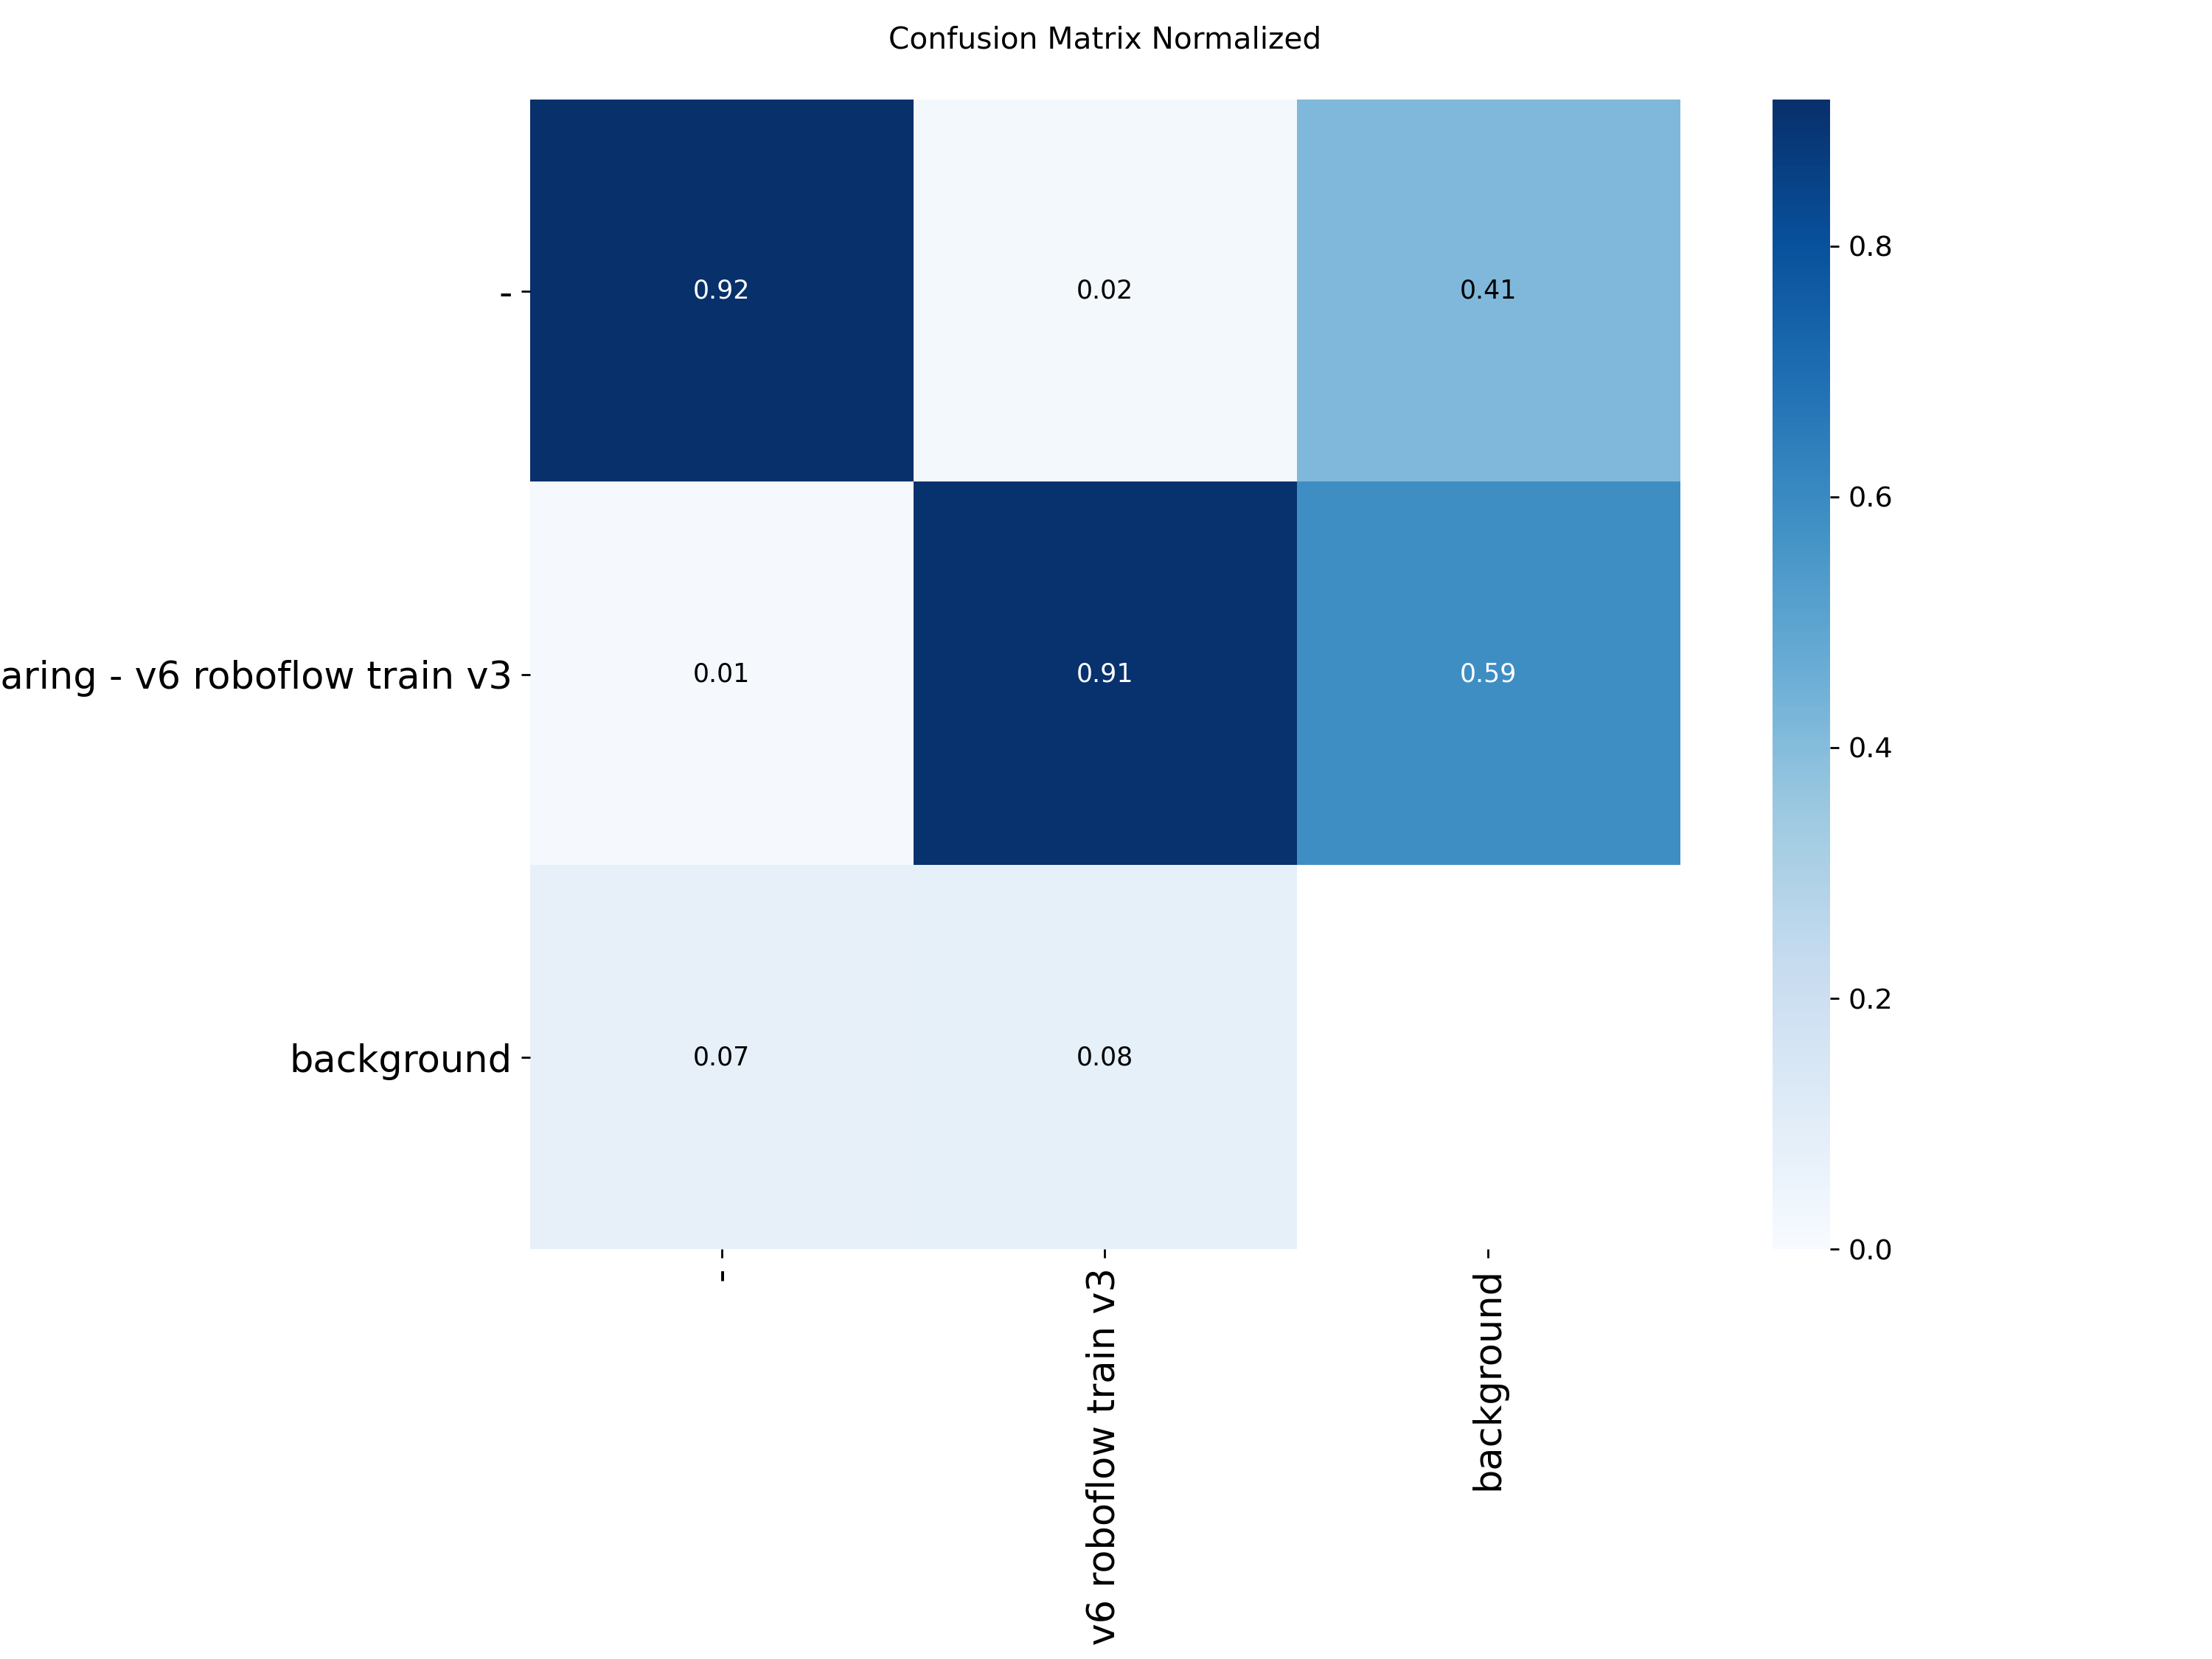

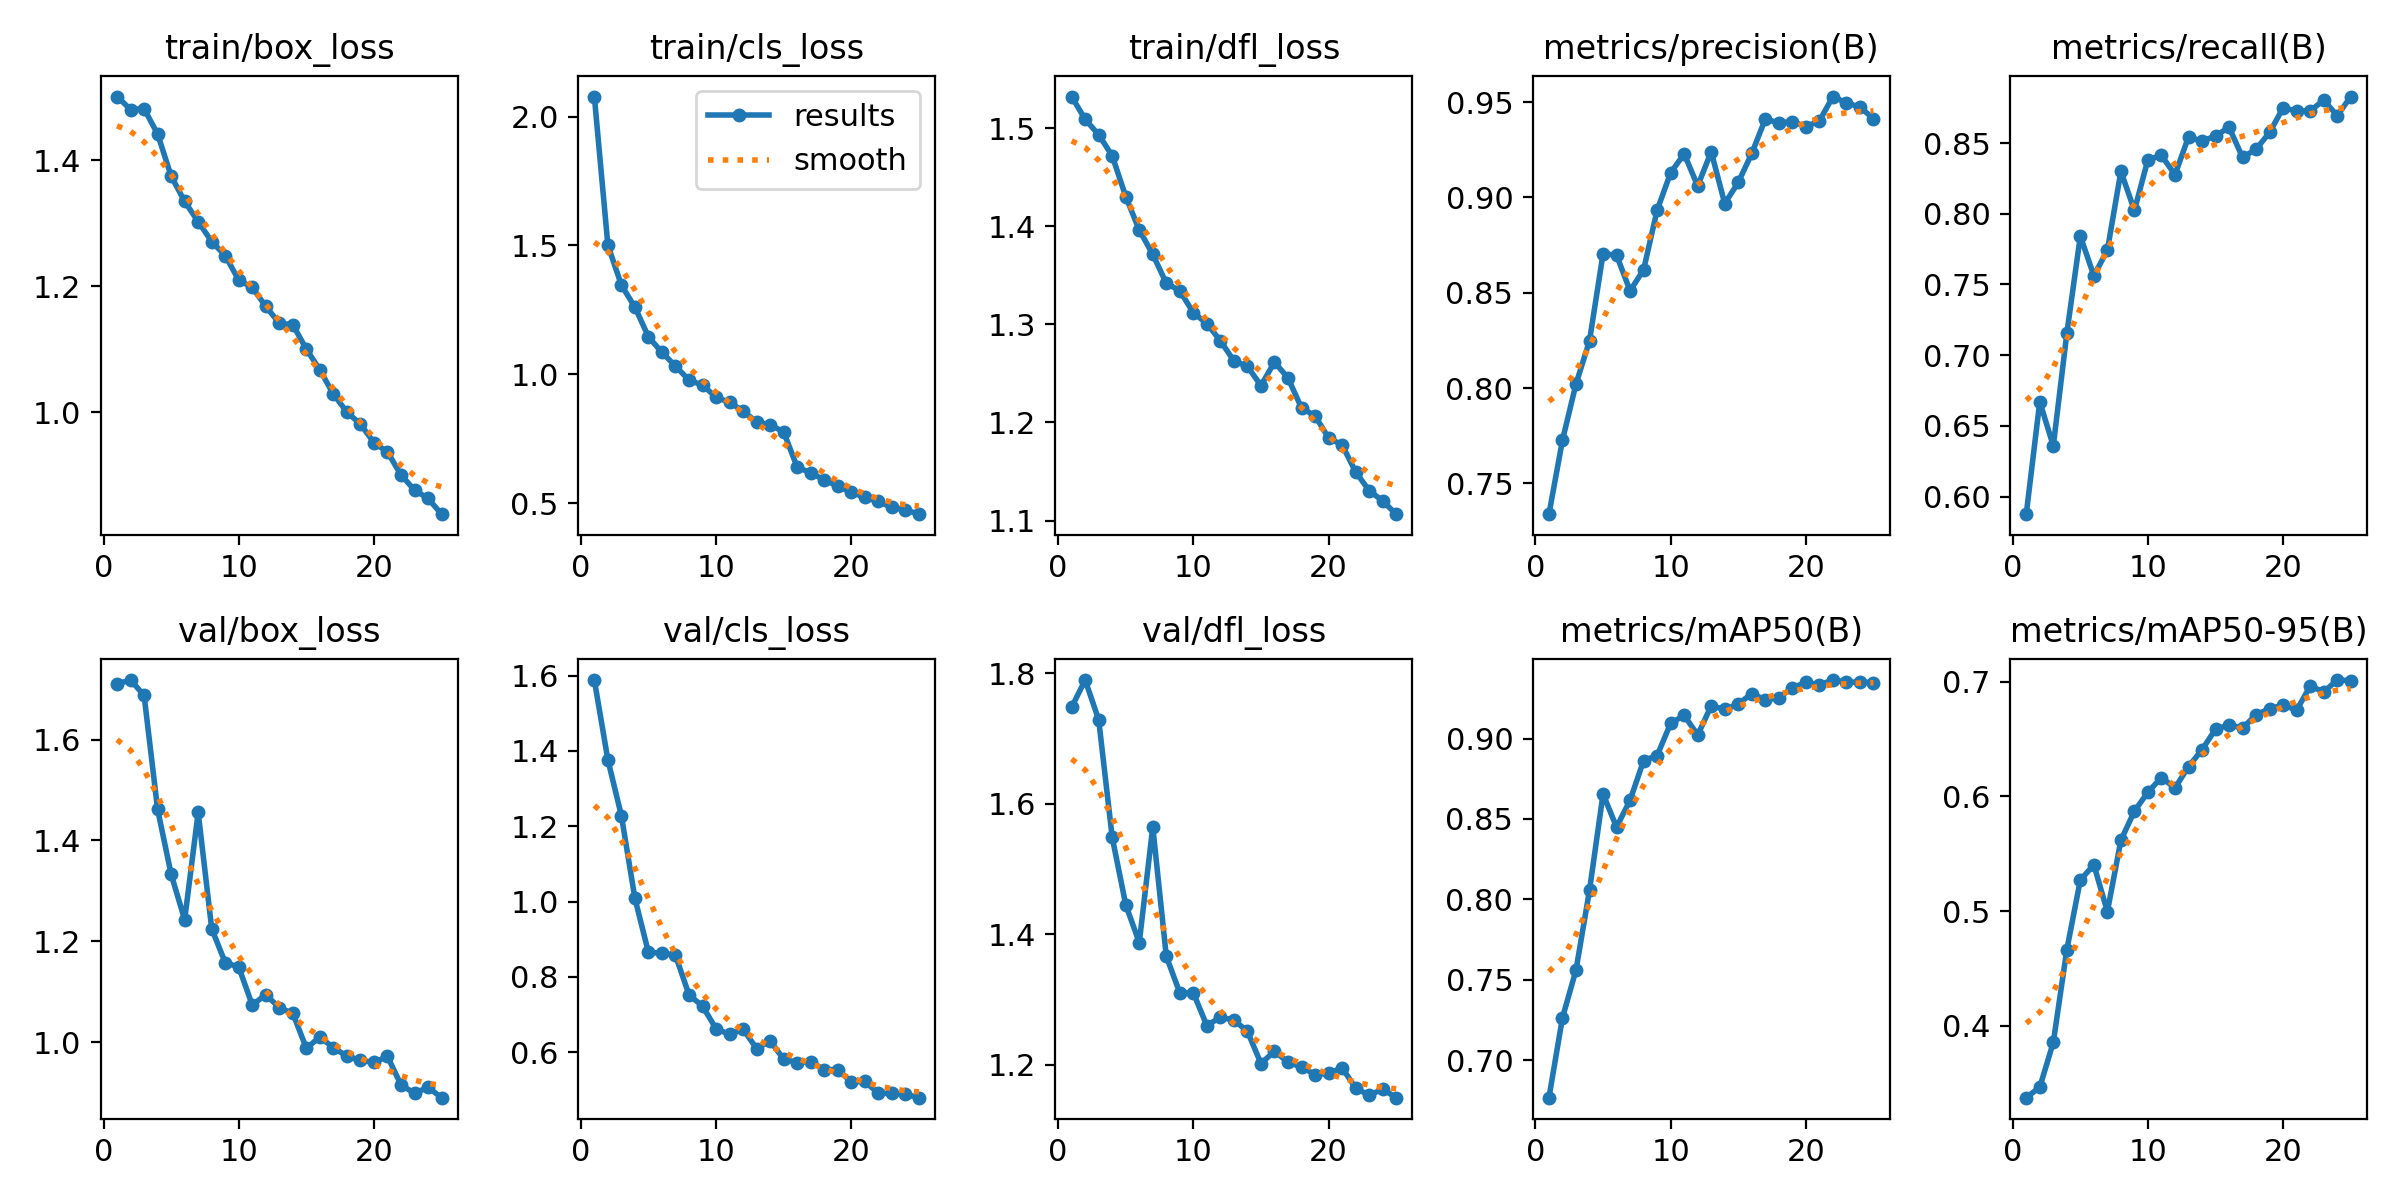

In [21]:
from IPython.display import Image,display
result_data ="/kaggle/working/runs/detect/train"
display(Image(filename=f"{result_data}/confusion_matrix_normalized.png"))
display(Image(filename=f"{result_data}/results.png"))